## Análisis Bivariable de los datos

### By: Maricel Martinez

### Date: 2026-08-27

### Description:

Análisis exploratorio bivariable (EDA) para estudiar las relaciones entre la variable objetivo `medv` y las demás variables, y entre pares de variables predictoras.

### Alcance

Este notebook continúa el análisis exploratorio del proyecto `Precios-casas-Boston`, a partir del análisis univariable ya realizado (`03_EDA_univariable`). Se estudian relaciones entre pares de variables:

- `medv` vs variables numéricas continuas
- `medv` vs variables discretas/categóricas (`chas`, `rad`)
- Relaciones entre variables predictoras (numérica vs numérica, categórica vs categórica, categórica vs numérica)

No se desarrolla análisis multivariable ni modelamiento en este notebook.

## 📚 Import libraries

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.simplefilter(action="ignore", category=FutureWarning)

# Configuración

In [2]:
# configuration to show only 2 decimal places
pd.set_option("display.float_format", "{:.2f}".format)

# configuration for plots
sns.set_theme(style="whitegrid")

# Versiones

In [3]:
print("Python version:", sys.version)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

Python version: 3.12.13 (main, Aug  5 2026, 15:44:22) [Clang 22.1.3 ]
Pandas version: 3.0.5
Seaborn version: 0.13.2


## 💾 Load data

In [4]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet",
    engine="pyarrow",
)

# Comprensión general de los datos (recordatorio)

In [5]:
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 343 entries, 0 to 342
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     339 non-null    float64
 1   zn       343 non-null    float64
 2   indus    339 non-null    float64
 3   chas     343 non-null    float64
 4   nox      341 non-null    float64
 5   rm       340 non-null    float64
 6   age      342 non-null    float64
 7   dis      340 non-null    float64
 8   rad      342 non-null    float64
 9   tax      340 non-null    float64
 10  ptratio  342 non-null    float64
 11  black    341 non-null    float64
 12  lstat    343 non-null    float64
 13  medv     331 non-null    float64
dtypes: float64(14)
memory usage: 37.6 KB


In [6]:
print("Número de filas:", boston_df.shape[0])
print("Número de columnas:", boston_df.shape[1])

Número de filas: 343
Número de columnas: 14


# Definición de variables para el análisis bivariable

In [7]:
TARGET = "medv"

continuous_vars = [
    "crim", "zn", "indus", "nox", "rm", "age",
    "dis", "tax", "ptratio", "black", "lstat",
]

discrete_vars = ["chas", "rad"]

print("Variable objetivo:", TARGET)
print("Variables continuas:", continuous_vars)
print("Variables discretas/categóricas:", discrete_vars)

Variable objetivo: medv
Variables continuas: ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']
Variables discretas/categóricas: ['chas', 'rad']


### Interpretación de la definición de variables

Se mantiene la misma clasificación establecida en el análisis univariable: `medv` como variable objetivo, once variables continuas, y dos variables discretas/categóricas (`chas`, binaria; `rad`, con baja cardinalidad). Esta clasificación determina el tipo de gráfico y prueba adecuados para cada relación bivariable.

# medv vs variables numéricas continuas

## Correlación de Pearson con medv

In [8]:
correlation_with_target = (
    boston_df[continuous_vars + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)

correlation_with_target

rm         0.69
zn         0.35
black      0.34
dis        0.24
age       -0.36
nox       -0.41
crim      -0.41
tax       -0.43
indus     -0.46
ptratio   -0.49
lstat     -0.74
Name: medv, dtype: float64

### Interpretación de la correlación con medv

`rm` (0.69) y `lstat` (-0.74) son las variables con mayor asociación lineal con `medv`: `rm` de forma positiva y `lstat` de forma negativa. `ptratio` (-0.49), `indus` (-0.46), `tax` (-0.43), `crim` (-0.41) y `nox` (-0.41) muestran asociación negativa moderada. `zn` (0.35), `black` (0.34) y `dis` (0.24) muestran asociación positiva débil a moderada, y `age` (-0.36) negativa débil a moderada. Ninguna variable individual explica por completo la variabilidad de `medv`, lo que confirma la necesidad de un modelo multivariable en las siguientes etapas.

## Dispersión: medv vs cada variable continua

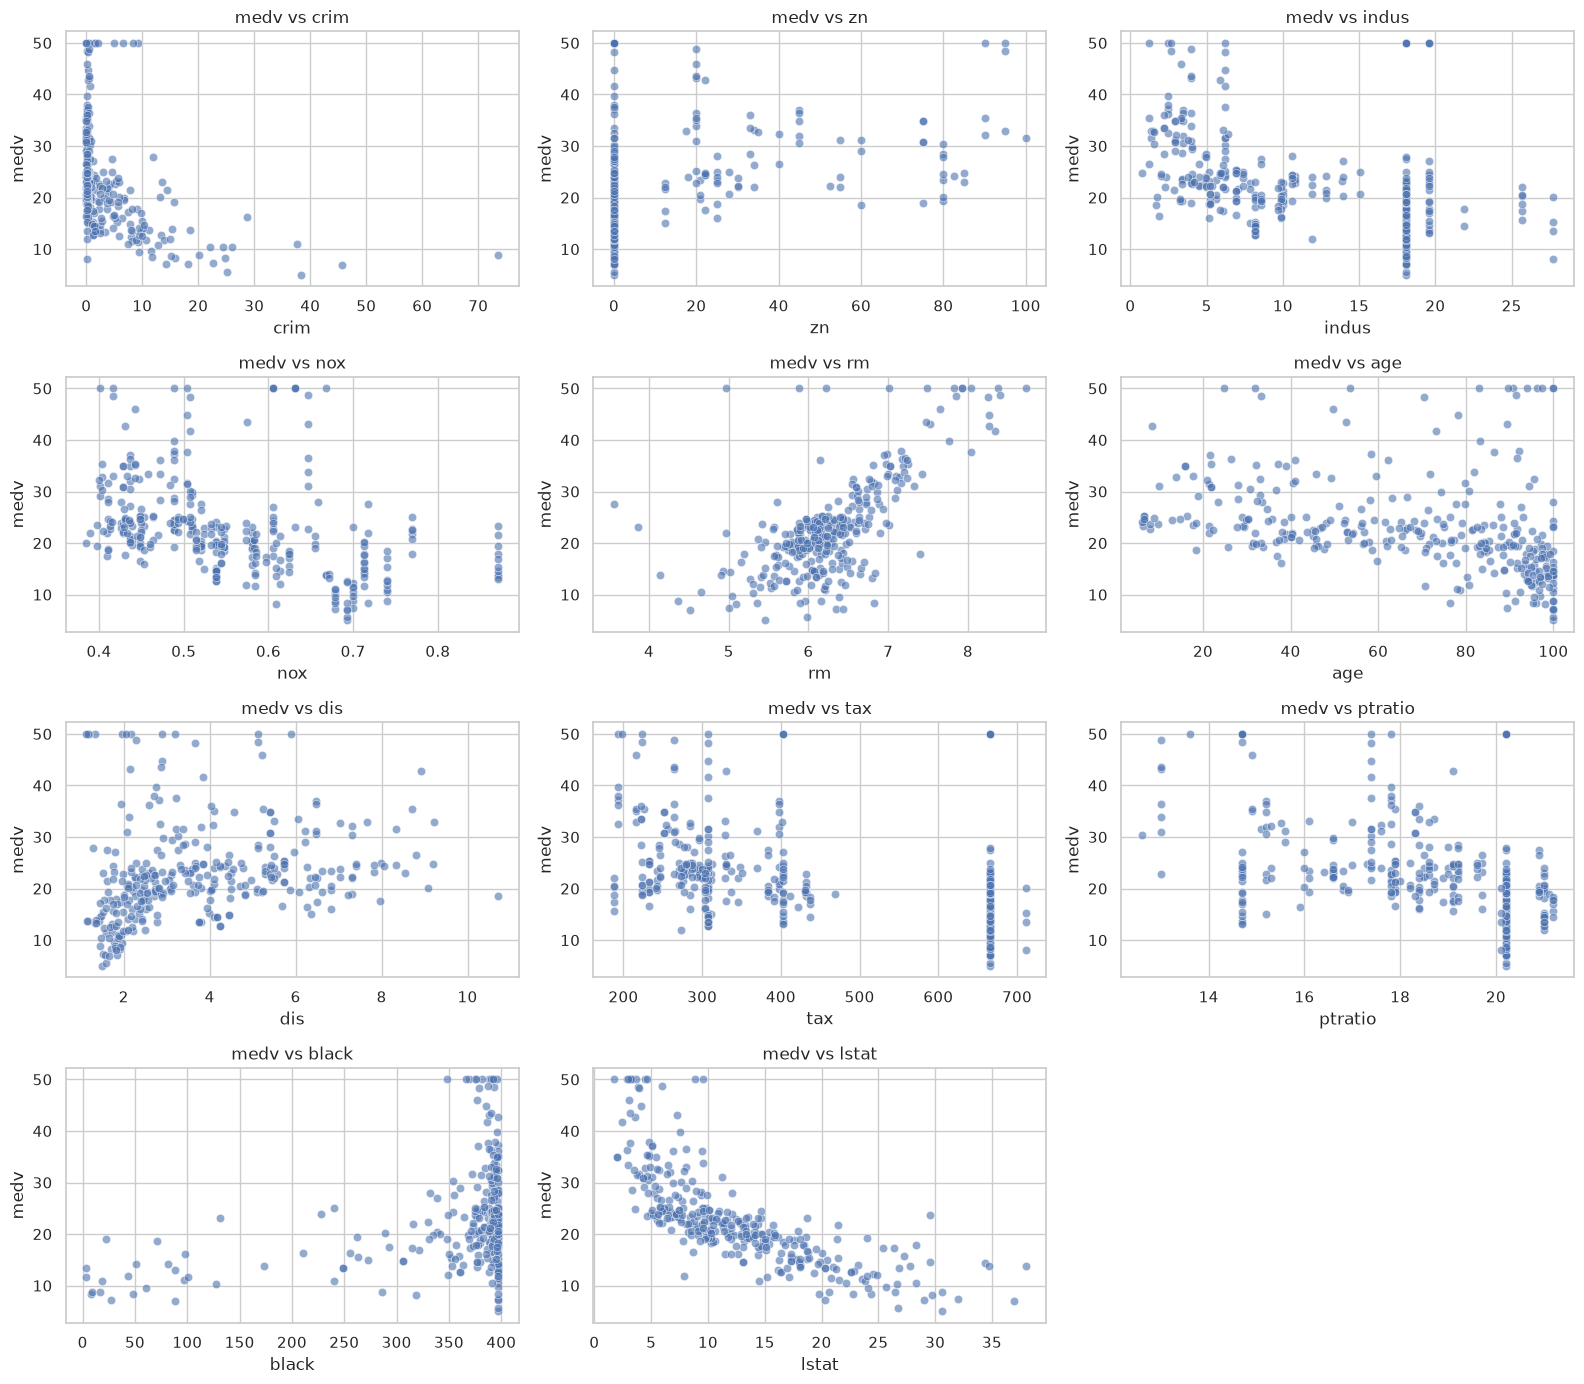

In [9]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.scatterplot(
        data=boston_df,
        x=col,
        y=TARGET,
        ax=axes[i],
        alpha=0.6,
    )
    axes[i].set_title(f"{TARGET} vs {col}")

for j in range(len(continuous_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Interpretación de los diagramas de dispersión

`rm` muestra la tendencia creciente más clara de todo el conjunto, consistente con su correlación de 0.69. `lstat` muestra una tendencia decreciente marcada, con forma ligeramente no lineal (curvatura descendente). El resto de variables muestra nubes de puntos más dispersas, sin un patrón lineal claro.

En prácticamente todos los diagramas se observa una línea horizontal de puntos en `medv = 50`, independientemente del valor de la variable en el eje X. Esto confirma la sospecha planteada en el análisis univariable: `medv` parece estar censurada o truncada en 50, ya que ese valor aparece de forma repetida y desconectada del comportamiento del resto de los datos. Este patrón deberá tenerse en cuenta en las siguientes etapas, ya sea filtrando esas observaciones o tratándolas de forma especial al modelar.

# medv vs variables discretas/categóricas

## medv vs chas

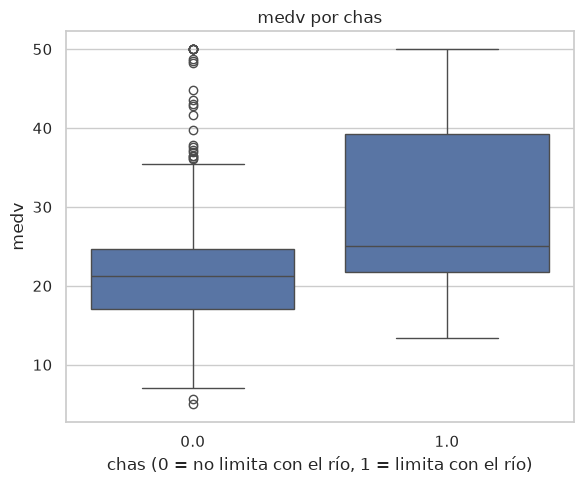

In [10]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=boston_df, x="chas", y=TARGET)
plt.title("medv por chas")
plt.xlabel("chas (0 = no limita con el río, 1 = limita con el río)")
plt.ylabel("medv")
plt.tight_layout()
plt.show()

In [ ]:
boston_df.groupby("chas", observed=True)[TARGET].agg(["mean", "median", "std", "count"])

### Interpretación de medv vs chas

El boxplot muestra que las viviendas con `chas = 1` tienen una mediana de `medv` notablemente más alta que las de `chas = 0`, además de un rango intercuartílico desplazado hacia valores más altos. Esto es consistente con la correlación positiva (0.19) observada, aunque su magnitud débil refleja que la diferencia entre grupos, aunque visible, no es muy pronunciada — y debe interpretarse con cautela dado el tamaño reducido del grupo `chas = 1` (ver análisis univariable). 

## medv vs rad

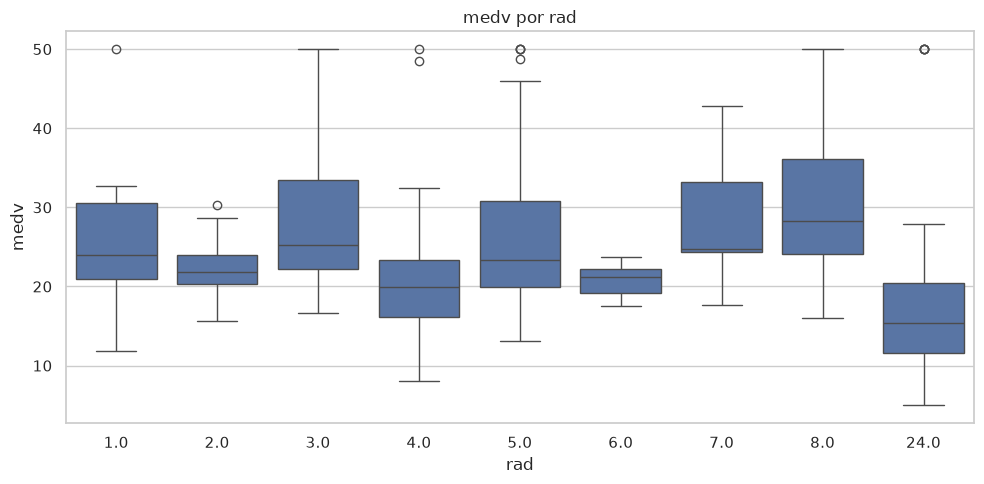

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=boston_df, x="rad", y=TARGET)
plt.title("medv por rad")
plt.xlabel("rad")
plt.ylabel("medv")
plt.tight_layout()
plt.show()

In [12]:
boston_df.groupby("rad", observed=True)[TARGET].agg(["mean", "median", "std", "count"]).sort_index()

,mean,median,std,count
rad,,,,
1.00,25.94,23.95,9.14,14
2.00,22.26,21.80,3.97,14
3.00,28.32,25.30,7.85,29
4.00,20.75,19.90,6.76,69
5.00,26.03,23.30,9.03,75
6.00,20.71,21.20,1.97,13
7.00,28.31,24.80,7.30,11
8.00,30.57,28.25,10.03,18
24.00,17.09,15.40,8.98,87


### Interpretación de medv vs rad

La tabla de medias por grupo confirma el patrón sugerido por la correlación (-0.35): el grupo `rad = 24` (87 observaciones, el más numeroso) tiene el precio medio más bajo (17.09) y la mediana más baja (15.40) de todos los grupos, muy por debajo del resto (medias entre 20.71 y 30.57). El boxplot muestra que este grupo no solo tiene menor mediana, sino también menor dispersión de precios altos. Esto sugiere que la correlación negativa entre `rad` y `medv` está impulsada en buena parte por este grupo específico y no por una tendencia decreciente uniforme a lo largo de todos los valores de `rad`.

# Matriz de correlación general

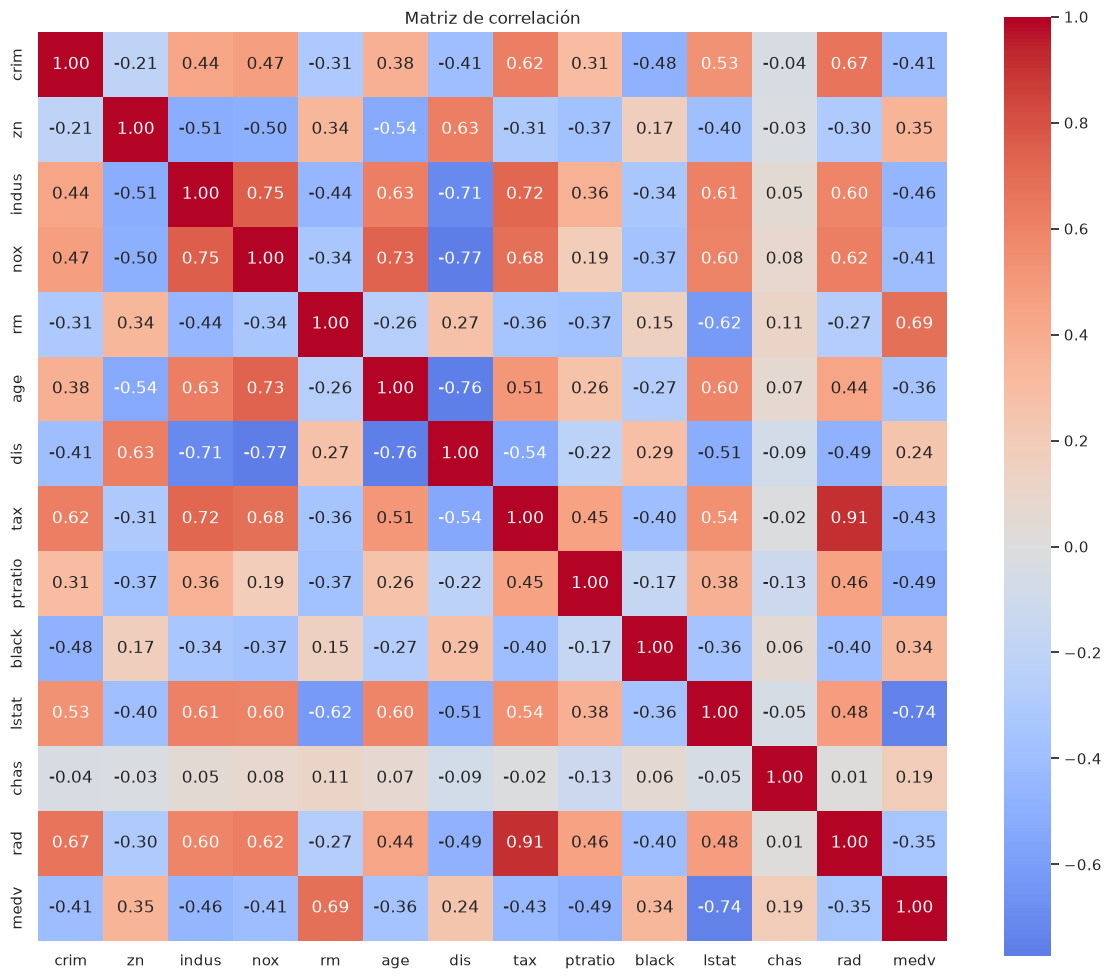

In [13]:
correlation_matrix = boston_df[continuous_vars + discrete_vars + [TARGET]].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Interpretación de la matriz de correlación

La fila de `medv` confirma los coeficientes ya revisados. Además, la matriz revela multicolinealidad fuerte entre varias predictoras: `tax` y `rad` (0.91) es la correlación más alta del dataset después de las de la diagonal, seguida de `nox`–`dis` (-0.77), `nox`–`age` (0.73), `nox`–`indus` (0.75) y `age`–`dis` (-0.76). Estas relaciones muy altas indican que varias variables comparten información redundante entre sí (posiblemente porque describen el mismo tipo de zona: industrial, contaminada y con acceso a autopistas), lo que deberá considerarse si se decide incluir todas las variables juntas en un modelo, para evitar problemas de estabilidad por colinealidad.

# Relaciones destacadas entre variables predictoras

## nox vs indus

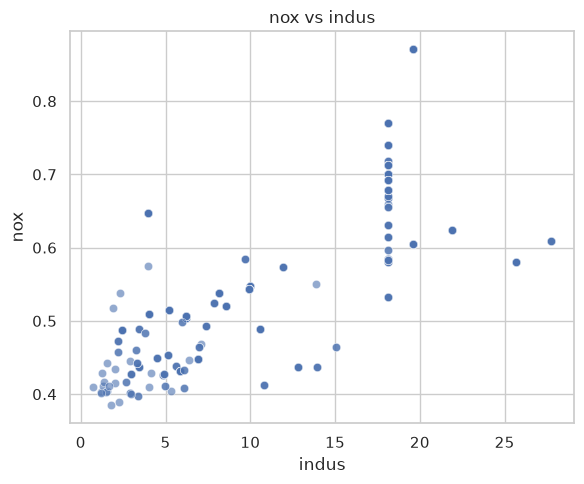

In [14]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=boston_df, x="indus", y="nox", alpha=0.6)
plt.title("nox vs indus")
plt.tight_layout()
plt.show()

## dis vs nox

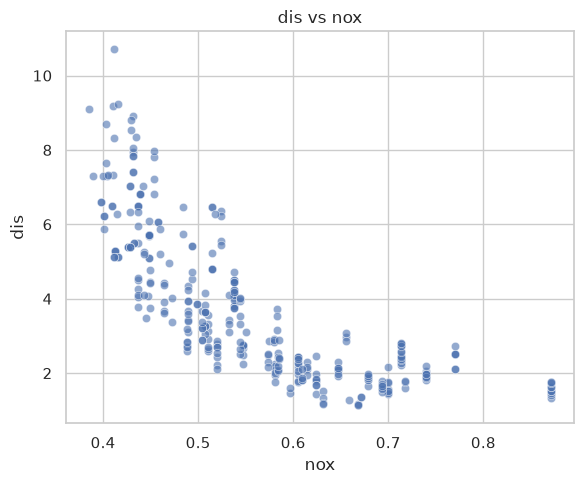

In [15]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=boston_df, x="nox", y="dis", alpha=0.6)
plt.title("dis vs nox")
plt.tight_layout()
plt.show()

## tax vs rad (categórica vs numérica)

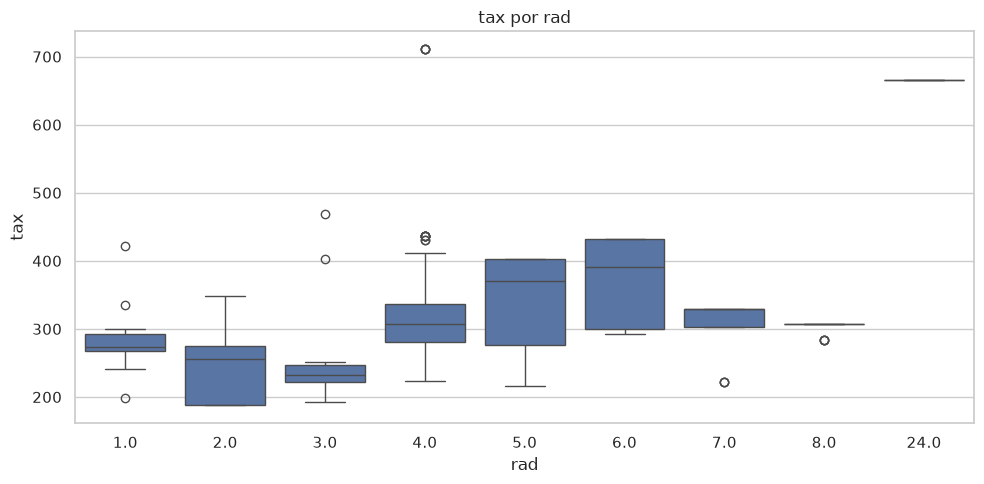

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=boston_df, x="rad", y="tax")
plt.title("tax por rad")
plt.xlabel("rad")
plt.ylabel("tax")
plt.tight_layout()
plt.show()

### Interpretación de las relaciones entre predictoras

`nox` vs `indus` muestra una relación creciente clara, con un salto notable: la mayoría de las zonas con `indus` alto (alrededor de 18) se concentran en niveles de `nox` altos, consistente con su correlación de 0.75. `dis` vs `nox` muestra una relación decreciente con forma de curva (no lineal): a mayor contaminación (`nox`), menor distancia a centros de empleo (`dis`), con la mayor parte de la caída ocurriendo en niveles bajos de `nox`.

El boxplot de `tax` por `rad` explica el porqué de la correlación de 0.91 entre ambas: el grupo `rad = 24` tiene un valor de `tax` prácticamente constante en 666, muy por encima y con casi ninguna variabilidad respecto a los demás grupos (que oscilan entre 200 y 430 aproximadamente). Esto indica que la relación `tax`–`rad` no es una tendencia lineal gradual, sino que está dominada por un solo grupo de zonas con impuesto fijo y accesibilidad máxima a autopistas — el mismo grupo que en la sección anterior mostró los precios (`medv`) más bajos.

# chas vs rad (categórica vs categórica)

In [17]:
(
    pd.crosstab(boston_df["chas"], boston_df["rad"], margins=True)
    .style.background_gradient(cmap="coolwarm")
    .set_caption("chas vs rad")
)

rad,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,24.000000,All
chas,,,,,,,,,,
0.000000,13,14,31,71,71,13,12,14,83,322
1.000000,1,0,1,3,6,0,0,4,5,20
All,14,14,32,74,77,13,12,18,88,342


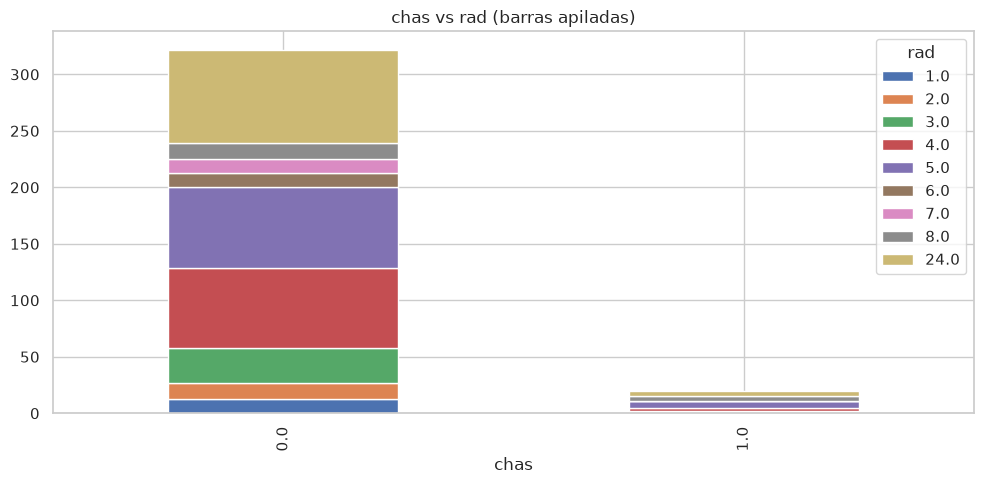

In [18]:
(
    pd.crosstab(boston_df["chas"], boston_df["rad"]).plot(
        kind="bar", stacked=True, title="chas vs rad (barras apiladas)", figsize=(10, 5)
    )
)
plt.tight_layout()
plt.show()

### Interpretación de chas vs rad

De las 342 observaciones con ambos valores no nulos, 322 tienen `chas = 0` y solo 20 tienen `chas = 1`. Dentro del grupo `chas = 1`, la distribución por `rad` no se concentra especialmente en ningún valor: hay observaciones repartidas entre varias categorías, con un máximo de 6 en `rad = 5` y 5 en `rad = 24`. Dado el tamaño tan reducido del grupo `chas = 1` frente al total, cualquier patrón entre estas dos variables debe interpretarse con cautela — no hay evidencia clara de que la ubicación junto al río esté asociada a un tipo particular de accesibilidad a autopistas.

## 📊 Análisis de resultados

`rm` y `lstat` son las variables individuales más fuertemente asociadas con `medv` (0.69 y -0.74 respectivamente). `ptratio`, `indus`, `tax`, `crim` y `nox` muestran asociación negativa moderada, mientras que `zn`, `black` y `dis` muestran asociación positiva débil a moderada.

Un hallazgo relevante de este análisis es que la variable objetivo `medv` presenta un patrón visible de censura en su valor máximo (50), observable como una línea horizontal de puntos en prácticamente todos los diagramas de dispersión, independientemente de la variable predictora. Este patrón ya se había sospechado en el análisis univariable (mediante la coincidencia entre moda y máximo) y ahora se confirma visualmente.

`chas` muestra una asociación débil con `medv` (0.19), pero el boxplot sugiere una diferencia visible entre grupos que debe confirmarse con las medias exactas. `rad` muestra una asociación negativa moderada con `medv` (-0.35), impulsada principalmente por el grupo `rad = 24` (el más numeroso, con el precio medio más bajo del dataset).

La matriz de correlación general revela multicolinealidad fuerte entre varias predictoras, en particular `tax`–`rad` (0.91), explicada por el mismo grupo `rad = 24`, que tiene un valor de `tax` casi constante (666). También se observa colinealidad relevante entre `nox`, `indus`, `age` y `dis`, variables que parecen describir un mismo tipo de zona industrial y contaminada. Esta redundancia entre predictoras deberá considerarse cuidadosamente antes de construir un modelo con todas las variables.

## 💡 Propuestas e ideas

`rm` y `lstat` son las variables más prometedoras para un primer modelo simple o heurístico de predicción de `medv`, dado que son las que muestran mayor asociación individual y patrones visualmente más consistentes en los diagramas de dispersión.

Para las siguientes etapas se recomienda:

- Investigar y decidir el tratamiento de la posible censura de `medv` en 50 (por ejemplo, excluir esas observaciones del entrenamiento o tratarlas como un caso especial), ya que puede sesgar cualquier modelo de regresión.
- Evitar incluir `tax` y `rad` simultáneamente sin ajustes, dada su correlación de 0.91; lo mismo aplica al grupo `nox`–`indus`–`age`–`dis`, que comparte información redundante.
- Evaluar si `rad` debe tratarse como categórica (codificación dummy/one-hot), dado que su relación con `medv` y con `tax` está dominada por un solo grupo (`rad = 24`) y no por una tendencia lineal gradual.
- Completar el análisis de `chas` con las medias exactas por grupo antes de decidir su inclusión en un modelo.
- Considerar el análisis multivariable para evaluar el efecto conjunto de `rm`, `lstat` y otras variables sobre `medv`, controlando por la multicolinealidad detectada.

## 📖 References

- Ejemplo de análisis bivariable (dataset Titanic) — Jose R. Zapata, profesor del curso.
- https://joserzapata.github.io/courses/python-ciencia-datos/visualizacion/seaborn/
- https://www.analyticsvidhya.com/blog/2022/02/a-quick-guide-to-bivariate-analysis-in-python/